OBJECTIVE: 

Analyse long-term temperature anomalies and their relationship with CO₂ levels to understand climate trend acceleration and its potential implications.

EXECUTIVE SUMMARY:
- Temperature anomalies have increased significantly post-1980.
- Rate of increase has accelerated compared to earlier periods.
- Long-term trends in increase in temperature aligns with rising CO₂ levels.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind


In [2]:
# Importing the required data 
temp = pd.read_csv("GLB.Ts+dSST.csv", skiprows=1)
co2 = pd.read_csv("co2_mm_mlo.csv", skiprows=40)

In [7]:
# Filtering the required rows for analysis
temp_clean = temp[['Year', 'J-D']].copy()
temp_clean.columns=['Year', 'Temperature_anomaly']

print(temp_clean.head())

   Year Temperature_anomaly
0  1880                -.17
1  1881                -.08
2  1882                -.11
3  1883                -.17
4  1884                -.28


In [8]:
temp_all = temp_clean.copy()

In [9]:
# Checking data types and null/missing values
temp_all['Temperature_anomaly'] = pd.to_numeric(temp_all['Temperature_anomaly'], errors='coerce')
print(temp_all.dtypes)

print(temp_all.isna().sum())
temp_all.dropna(subset=['Temperature_anomaly'], inplace=True)

Year                     int64
Temperature_anomaly    float64
dtype: object
Year                   0
Temperature_anomaly    1
dtype: int64


In [10]:
# Splitting time-period into pre-1900, 1900-1980 and post-1980
pre_1900 = temp_all[temp_all['Year']<1900]
yr_1900_1980 = temp_all[(temp_all['Year']>=1900) & (temp_all['Year']<1980)]
post_1980 = temp_all[temp_all['Year']>=1980]

periods=[pre_1900, yr_1900_1980, post_1980]

In [11]:
pre_1900_vals = temp_all[temp_all['Year']<1900]['Temperature_anomaly']
grp_1900_1980_vals = temp_all[(temp_all['Year']>=1900) & (temp_all['Year']<1980)]['Temperature_anomaly']
post_1980_vals = temp_all[temp_all['Year']>=1980]['Temperature_anomaly']    

In [12]:
# Identifying the mean temperatures across the 3 periods

pre_1900_m = pre_1900_vals.mean()
yr_1900_1980_m = grp_1900_1980_vals.mean()
post_1980_m = post_1980_vals.mean()

print(f"Pre-1900 : {pre_1900_m:.4f} °C")
print(f"Post-1900 baseline: {yr_1900_1980_m:.4f} °C")
print(f"Post-1980 : {post_1980_m:.4f} °C")


Pre-1900 : -0.2245 °C
Post-1900 baseline: -0.1266 °C
Post-1980 : 0.5778 °C


This indicates not just a gradual increase, but a structural acceleration in warming after 1980. The post-1980 period shows a ~0.70 °C rise relative to the 1900–1980 baseline, highlighting a significant deviation from historical trends rather than normal variability.

In [13]:
# One-Way ANOVA test
from scipy.stats import f_oneway
f_stat, p_val = f_oneway(pre_1900_vals, grp_1900_1980_vals, post_1980_vals)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.6f}")

F-statistic: 181.6534
p-value: 0.000000


A one-way ANOVA test was conducted to compare mean temperature anomalies across three time periods. The results indicate a statistically significant difference between groups (p < 0.05), suggesting that temperature patterns have changed over time rather than remaining constant.

In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

values = np.concatenate([pre_1900_vals, grp_1900_1980_vals, post_1980_vals])
groups = (
    ['Pre-1900'] * len(pre_1900_vals) +
    ['1900-1980'] * len(grp_1900_1980_vals) +
    ['Post-1980'] * len(post_1980_vals)
)

tukey = pairwise_tukeyhsd(values, groups, alpha=0.05)
print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
1900-1980 Post-1980   0.7045    0.0  0.6106  0.7983   True
1900-1980  Pre-1900  -0.0979 0.1642 -0.2247   0.029  False
Post-1980  Pre-1900  -0.8023    0.0 -0.9382 -0.6664   True
----------------------------------------------------------


Tukey HSD post-hoc analysis reveals that the post-1980 period is significantly different from both earlier periods (p < 0.05), with mean temperature anomalies increasing by ~0.70–0.80 °C.
In contrast, no statistically significant difference is observed between the pre-1900 and 1900–1980 periods.

This indicates that the primary shift in temperature patterns occurs after 1980, suggesting a clear structural break rather than a gradual long-term increase.

C:\Users\Deepika\AppData\Local\Temp\ipykernel_4684\1964373852.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


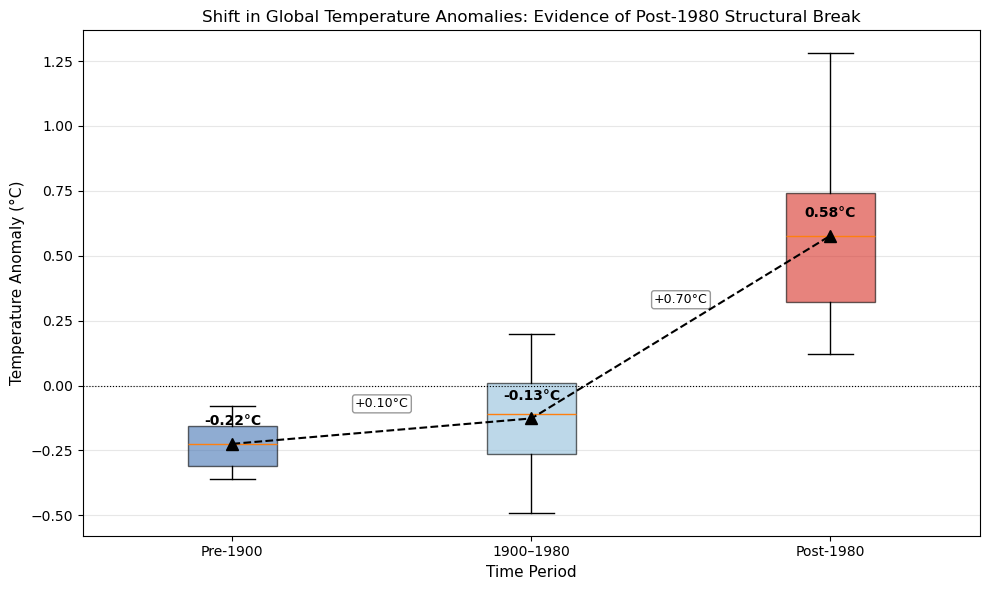

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

# Box plot with mean marker shown as triangle
bp = ax.boxplot(
    [pre_1900_vals, grp_1900_1980_vals, post_1980_vals],
    labels=['Pre-1900', '1900–1980', 'Post-1980'],
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='^', markerfacecolor='black', markeredgecolor='black', markersize=8)
)

# Colour each box by era
colors = ['#4575b4', '#91bfdb', '#d73027']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Mean values — offset above the triangle marker to avoid overlap
means = [pre_1900_m, yr_1900_1980_m, post_1980_m]
x_positions = [1, 2, 3]
offsets = [0.06, 0.06, 0.06]   # nudge text above marker

for x, mean, offset in zip(x_positions, means, offsets):
    ax.text(x, mean + offset, f'{mean:.2f}°C',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Connect means with a trend line
ax.plot(x_positions, means,
        color='black', linewidth=1.5, linestyle='--',
        marker=None, zorder=5)

# Annotate slope between each consecutive pair
pairs = [(0, 1), (1, 2)]
labels_pairs = ['Pre-1900 → 1900–1980', '1900–1980 → Post-1980']

for (i, j), lbl in zip(pairs, labels_pairs):
    x_mid = (x_positions[i] + x_positions[j]) / 2
    y_mid = (means[i] + means[j]) / 2
    delta = means[j] - means[i]
    sign = '+' if delta >= 0 else ''
    ax.text(x_mid, y_mid + 0.08, f'{sign}{delta:.2f}°C',
            ha='center', va='bottom', fontsize=9,
            color='black',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='grey', alpha=0.8))

ax.set_xlabel('Time Period', fontsize=11)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=11)
ax.set_title('Shift in Global Temperature Anomalies: Evidence of Post-1980 Structural Break', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The distribution of temperature anomalies remains largely consistent between the pre-1900 and 1900–1980 periods, with substantial overlap in both median values and variability.

In contrast, the post-1980 period exhibits a clear upward shift, with the entire distribution moving into positive anomaly territory. The lack of overlap with earlier periods indicates a structural break rather than a gradual trend, reinforcing statistical findings from ANOVA and post-hoc testing.

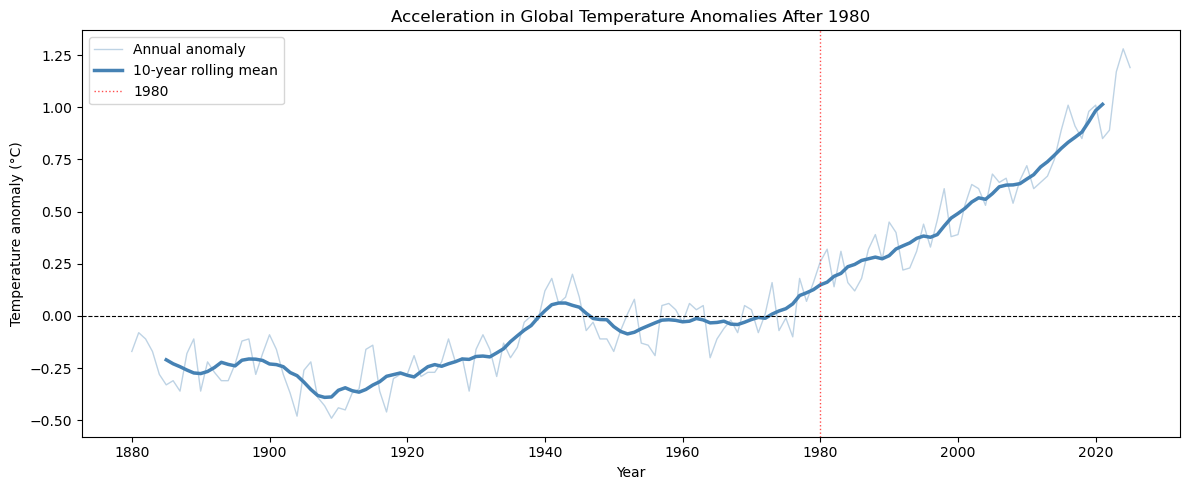

In [16]:
rolling = temp_all['Temperature_anomaly'].rolling(window=10, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(temp_all['Year'], temp_all['Temperature_anomaly'],
        color='steelblue', alpha=0.35, linewidth=1, label='Annual anomaly')

ax.plot(temp_all['Year'], rolling,
        color='steelblue', linewidth=2.5, label='10-year rolling mean')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(1980, color='red', linewidth=1, linestyle=':', alpha=0.7, label='1980')

ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_title('Acceleration in Global Temperature Anomalies After 1980')
ax.legend()
plt.tight_layout()
plt.show()

The chart shows a clear long-term upward trend in global temperature anomalies from 1880 to 2025.

While annual temperatures fluctuate year to year, the 10-year rolling average indicates that temperatures remained relatively stable for much of the early and mid-20th century before accelerating sharply after 1980.The post-1980 period marks a sustained shift into positive temperature anomalies, with the rate of increase becoming progressively steeper over time.

This suggests that recent warming is not driven by short-term variability alone, but reflects a persistent structural change in global temperature patterns.

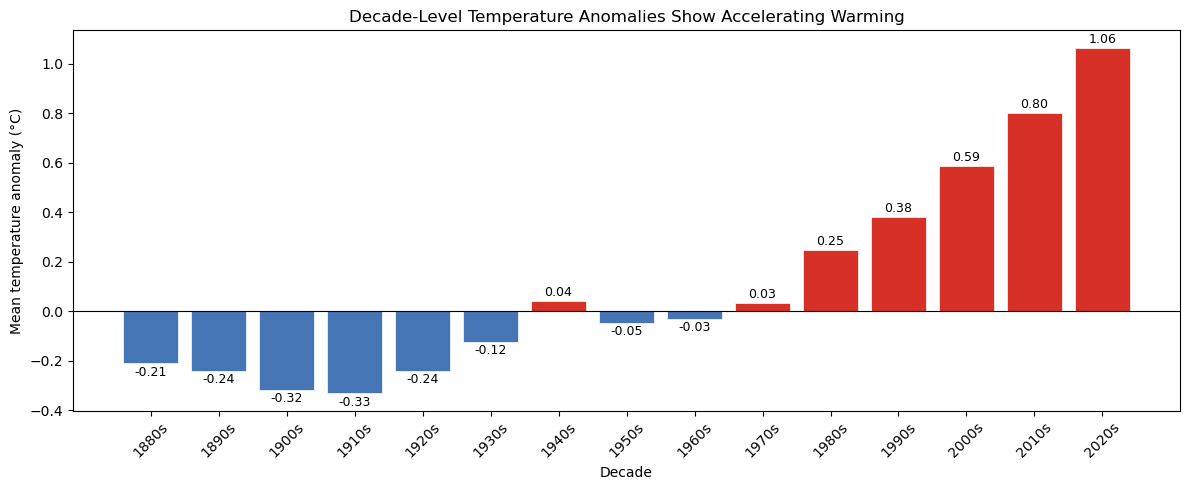

In [17]:
temp_all['Decade'] = (temp_all['Year'] // 10) * 10
decade_mean = temp_all.groupby('Decade')['Temperature_anomaly'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#d73027' if v > 0 else '#4575b4' for v in decade_mean.values]

ax.bar(decade_mean.index, decade_mean.values,
       width=8, color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Decade')
ax.set_ylabel('Mean temperature anomaly (°C)')
ax.set_title('Decade-Level Temperature Anomalies Show Accelerating Warming')
ax.set_xticks(decade_mean.index)
ax.set_xticklabels([f"{d}s" for d in decade_mean.index], rotation=45)

for decade, val in zip(decade_mean.index, decade_mean.values):
    ax.text(decade, val + (0.02 if val >= 0 else -0.05),
            f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

The decade-level aggregation reduces short-term variability and highlights a persistent upward trajectory in global temperatures. The sharp increase observed from the 1980s onward supports the presence of a long-term structural shift rather than temporary fluctuations.

In [18]:
from scipy.stats import linregress

# Full period
full = linregress(temp_all['Year'], temp_all['Temperature_anomaly'])

# Pre-1900 (you already have pre_1900_vals)
pre  = linregress(
    temp_all[temp_all['Year'] < 1900]['Year'],
    temp_all[temp_all['Year'] < 1900]['Temperature_anomaly']
)

mid = linregress(
    temp_all[(temp_all['Year'] >= 1900) & (temp_all['Year'] < 1980)]['Year'],
    temp_all[(temp_all['Year'] >= 1900) & (temp_all['Year'] < 1980)]['Temperature_anomaly'] 
)
# Post-1980 (you already have this too)
post = linregress(
    temp_all[temp_all['Year'] >= 1980]['Year'],
    temp_all[temp_all['Year'] >= 1980]['Temperature_anomaly']
)

print(f"Full 1880–2025:  {full.slope*10:.4f} °C/decade  R²={full.rvalue**2:.3f}  p={full.pvalue:.2e}")
print(f"Pre-1900:        {pre.slope*10:.4f} °C/decade  R²={pre.rvalue**2:.3f}  p={pre.pvalue:.2e}")
print(f"Mid-1900 to 1980: {mid.slope*10:.4f} °C/decade  R²={mid.rvalue**2:.3f}  p={mid.pvalue:.2e}")
print(f"Post-1980:       {post.slope*10:.4f} °C/decade  R²={post.rvalue**2:.3f}  p={post.pvalue:.2e}")

Full 1880–2025:  0.0827 °C/decade  R²=0.764  p=5.15e-47
Pre-1900:        -0.0160 °C/decade  R²=0.011  p=6.64e-01
Mid-1900 to 1980: 0.0550 °C/decade  R²=0.541  p=8.11e-15
Post-1980:       0.2078 °C/decade  R²=0.872  p=3.10e-21


Linear regression analysis shows that the rate of temperature increase accelerated significantly after 1980.

Earlier periods exhibit relatively weak or gradual warming trends, whereas the post-1980 period demonstrates a substantially steeper slope and stronger model fit, indicating a sustained and statistically significant increase in global temperature anomalies.

CO2 Vs Temperature

In [19]:
# Replace invalid values
co2['average'] = co2['average'].replace(-99.99, pd.NA)

# Convert to numeric
co2['average'] = pd.to_numeric(co2['average'], errors='coerce')

# Drop missing
co2 = co2.dropna(subset=['average'])

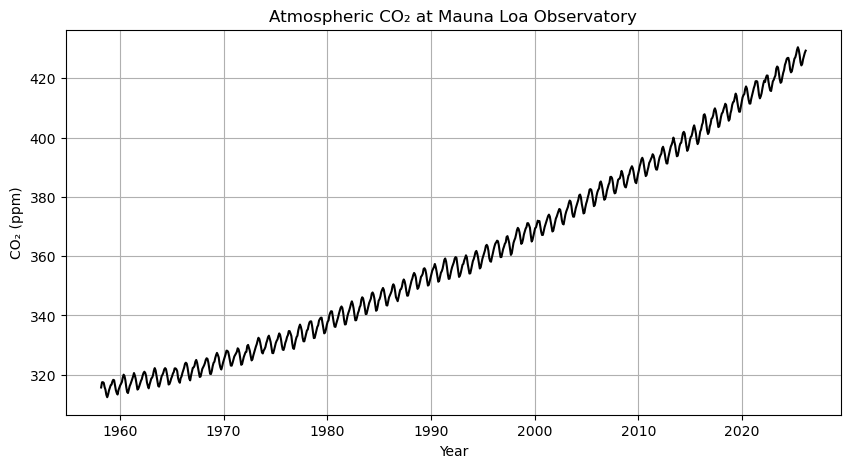

In [20]:
plt.figure(figsize=(10,5))

plt.plot(co2['decimal date'], co2['average'], color='black')

plt.xlabel("Year")
plt.ylabel("CO₂ (ppm)")
plt.title("Atmospheric CO₂ at Mauna Loa Observatory")
plt.grid(True)
plt.show()

Atmospheric CO₂ concentrations show a persistent upward trend from the late 1950s onward, increasing from approximately 315 ppm to over 425 ppm.

While short-term seasonal fluctuations are visible, the long-term trajectory remains consistently upward, indicating sustained accumulation of atmospheric carbon dioxide over time.

In [21]:
co2_yearly = co2.groupby('year')['average'].mean().reset_index()
co2_yearly.columns = ['Year', 'Co2']

In [22]:
print(co2_yearly.head())
print(co2_yearly.shape)

   Year         Co2
0  1958  315.237000
1  1959  315.981667
2  1960  316.908333
3  1961  317.643333
4  1962  318.453333
(69, 2)


In [23]:
temp_clean = temp_clean[temp_clean['Year']>=1958].reset_index()

In [24]:
merged = pd.merge(temp_clean, co2_yearly, on='Year', how='inner')
print(merged.tail())
print(merged.isna().sum())
merged['Temperature_anomaly'] = pd.to_numeric(merged['Temperature_anomaly'], errors='coerce')
merged.dropna(inplace=True)   
print(merged.dtypes)


    index  Year Temperature_anomaly         Co2
64    142  2022                 .89  418.528333
65    143  2023                1.17  421.075833
66    144  2024                1.28  424.604167
67    145  2025                1.19  427.349167
68    146  2026                 ***  428.985000
index                  0
Year                   0
Temperature_anomaly    0
Co2                    0
dtype: int64
index                    int64
Year                     int64
Temperature_anomaly    float64
Co2                    float64
dtype: object


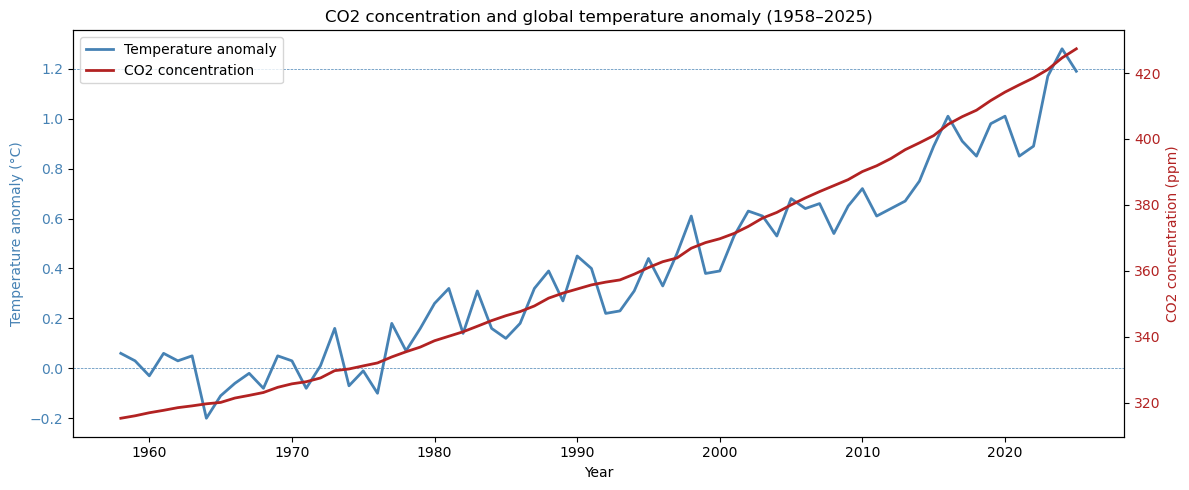

In [25]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(merged['Year'], merged['Temperature_anomaly'],
         color='steelblue', linewidth=2, label='Temperature anomaly')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature anomaly (°C)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(0, color='steelblue', linewidth=0.5, linestyle='--')
ax1.axhline(1.2, color='steelblue', linewidth=0.5, linestyle='--')

ax2 = ax1.twinx()
ax2.plot(merged['Year'], merged['Co2'],
         color='firebrick', linewidth=2, label='CO2 concentration')
ax2.set_ylabel('CO2 concentration (ppm)', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('CO2 concentration and global temperature anomaly (1958–2025)')
plt.tight_layout()
plt.show()

The dual-axis plot demonstrates that atmospheric CO₂ concentration and global temperature anomalies have moved upward together over time, particularly in recent decades. The divergence becomes more pronounced after 1980, where both indicators show accelerated growth. Despite periodic fluctuations in temperature anomalies, the overall trend suggests a strong positive relationship between greenhouse gas accumulation and long-term warming patterns.

0.9661825798099221


<Axes: >

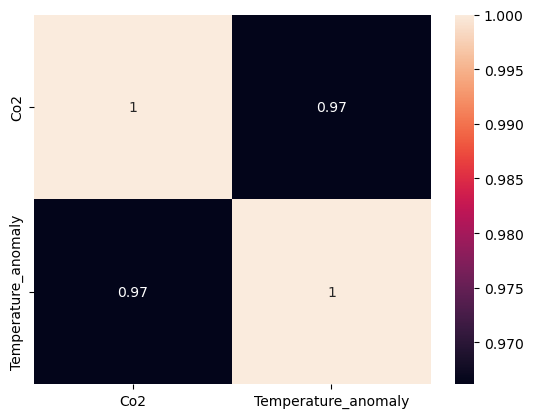

In [26]:
import seaborn as sns
print(merged['Co2'].corr(merged['Temperature_anomaly']))
corr_matrix = merged[['Co2', 'Temperature_anomaly']].corr()

sns.heatmap(corr_matrix, annot=True)

There is a strong positive correlation  between CO₂ concentration and temperature anomalies.

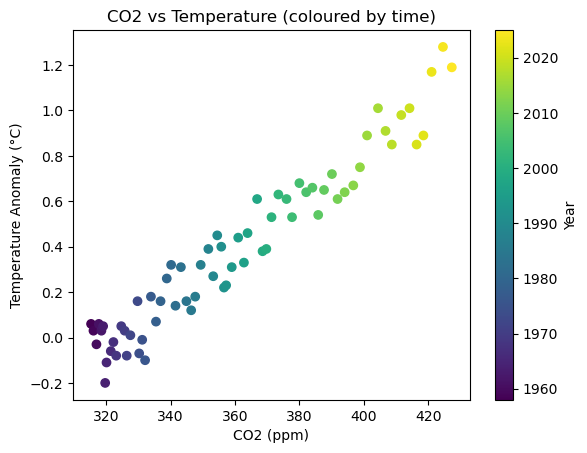

In [27]:
plt.scatter(merged['Co2'], merged['Temperature_anomaly'],
            c=merged['Year'], cmap='viridis')

plt.colorbar(label='Year')
plt.xlabel("CO2 (ppm)")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("CO2 vs Temperature (coloured by time)")
plt.show()

The scatter plot reveals a strong positive relationship between atmospheric CO₂ concentration and global temperature anomalies. As CO₂ levels increase, temperature anomalies also tend to rise, with relatively limited dispersion around the overall trend. The gradual upward spread of observations over time further suggests that warming intensifies alongside sustained increases in greenhouse gas concentrations.

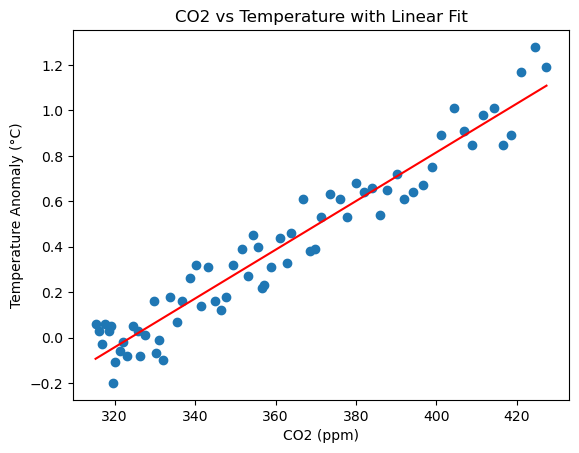

0.010731380927991259 -3.476671377363836


In [28]:
x = merged['Co2']
y = merged['Temperature_anomaly']

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x+b, color="red")
plt.xlabel("CO2 (ppm)")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("CO2 vs Temperature with Linear Fit")             
plt.show()  
print(m, b)

The fitted regression line indicates that temperature anomalies increase consistently as atmospheric CO₂ concentrations rise. The relatively close alignment between observed values and the regression trend suggests that CO₂ concentration explains a substantial proportion of long-term temperature variation. While some deviations remain due to natural climate variability and external factors, the overall relationship appears both statistically strong and directionally stable.

In [29]:
from scipy.stats import linregress

x = merged['Co2']
y = merged['Temperature_anomaly']

result = linregress(x, y)

print("Slope:", result.slope)
print("Intercept:", result.intercept)
print("R-squared:", result.rvalue**2)

Slope: 0.01073138092799127
Intercept: -3.4766713773638407
R-squared: 0.9335087775281564


The linear regression results indicate a strong positive relationship between atmospheric CO₂ concentration and global temperature anomalies. The high R² value (~0.93) suggests that CO₂ concentration explains a substantial proportion of the long-term variation observed in global temperatures, reinforcing the strength and consistency of the relationship.

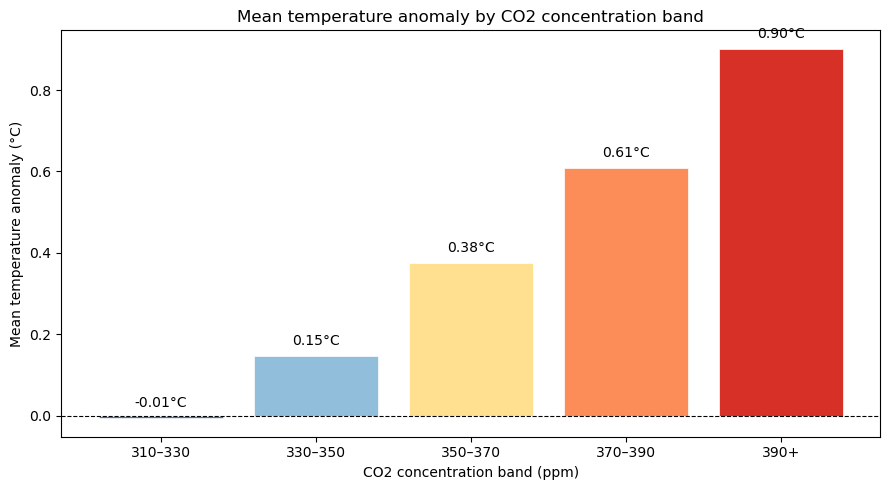

In [30]:
bins = [310, 330, 350, 370, 390, 430]
labels = ['310–330', '330–350', '350–370', '370–390', '390+']

merged['Co2_bin'] = pd.cut(merged['Co2'], bins=bins, labels=labels)
bin_means = merged.groupby('Co2_bin', observed=True)['Temperature_anomaly'].mean()

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4575b4', '#91bfdb', '#fee090', '#fc8d59', '#d73027']
bars = ax.bar(bin_means.index, bin_means.values,
              color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('CO2 concentration band (ppm)')
ax.set_ylabel('Mean temperature anomaly (°C)')
ax.set_title('Mean temperature anomaly by CO2 concentration band')

for bar, val in zip(bars, bin_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.2f}°C', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Grouping temperature anomalies by CO₂ concentration ranges highlights a progressive increase in average temperatures across higher atmospheric CO₂ bands. Lower concentration ranges are generally associated with smaller or near-neutral anomalies, whereas higher ranges correspond to significantly warmer conditions. This stepwise increase reinforces the broader evidence that rising greenhouse gas accumulation is closely associated with long-term warming trends.

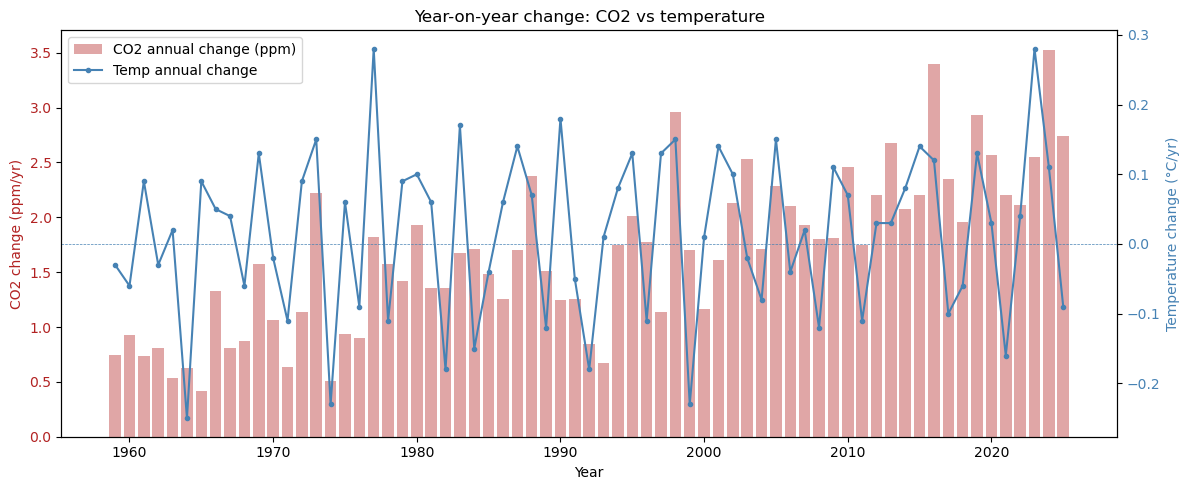

In [31]:
co2_change = merged['Co2'].diff()
temp_change = merged['Temperature_anomaly'].diff()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(merged['Year'], co2_change, color='firebrick', alpha=0.4,
        width=0.8, label='CO2 annual change (ppm)')
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 change (ppm/yr)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')

ax2 = ax1.twinx()
ax2.plot(merged['Year'], temp_change, color='steelblue',
         linewidth=1.5, marker='o', markersize=3, label='Temp annual change')
ax2.set_ylabel('Temperature change (°C/yr)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.axhline(0, color='steelblue', linewidth=0.5, linestyle='--')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Year-on-year change: CO2 vs temperature')
plt.tight_layout()
plt.show()

The year-on-year comparison highlights that atmospheric CO₂ concentrations have shown a relatively consistent upward increase over time, while annual temperature changes remain more volatile. Despite short-term fluctuations in temperature anomalies, periods of sustained CO₂ growth are generally accompanied by an upward warming trend over the long run. The increasing magnitude of annual CO₂ changes in recent decades suggests that greenhouse gas accumulation has accelerated, reinforcing longer-term warming patterns even when yearly temperature variations temporarily diverge from the trend.

In [32]:
merged['predicted'] = result.slope * merged['Co2'] + result.intercept
merged['residuals'] = merged['Temperature_anomaly'] - merged['predicted']

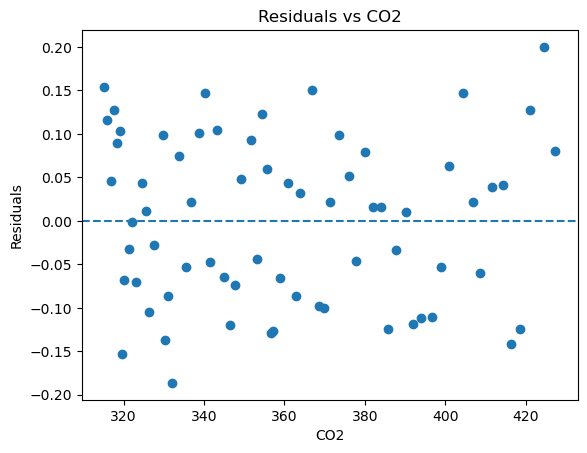

In [33]:
plt.scatter(merged['Co2'], merged['residuals'])
plt.axhline(y=0, linestyle='--')

plt.xlabel("CO2")
plt.ylabel("Residuals")
plt.title("Residuals vs CO2")

plt.show()

The residual distribution appears relatively balanced around zero across different CO₂ concentration levels, suggesting that the linear regression model captures the overall relationship reasonably well. While some variation remains, there is no strong systematic pattern in the residuals, indicating that the model errors are fairly random rather than consistently biased.

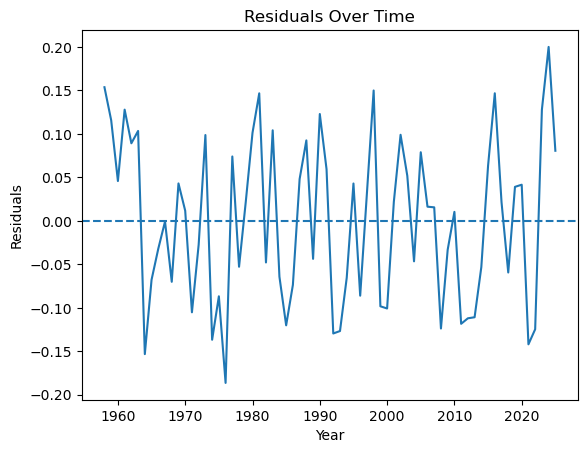

In [34]:
plt.plot(merged['Year'], merged['residuals'])
plt.axhline(y=0, linestyle='--')

plt.xlabel("Year")
plt.ylabel("Residuals")
plt.title("Residuals Over Time")

plt.show()

The residuals fluctuate around zero throughout the observed period without a persistent upward or downward trend. This suggests that the model maintains a relatively stable fit over time, although short-term deviations indicate that additional climatic and environmental factors may influence temperature anomalies beyond atmospheric CO₂ concentration alone.

FORECASTING

In [35]:
merged['Temp_diff'] = merged['Temperature_anomaly'].diff()
temp_series = merged['Temp_diff'].dropna()

In [36]:
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(temp_series)
print("p-value:", result_adf[1])

p-value: 0.06537470366093162


In [37]:
merged['Temp_diff'] = merged['Temp_diff'].diff()
temp_series = merged['Temp_diff'].dropna()

In [38]:
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(temp_series)
print("p-value:", result_adf[1])

p-value: 5.065369869471297e-07


In [39]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(merged['Temperature_anomaly'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     Temperature_anomaly   No. Observations:                   68
Model:                  ARIMA(1, 1, 1)   Log Likelihood                  51.659
Date:                 Fri, 08 May 2026   AIC                            -97.319
Time:                         01:01:22   BIC                            -90.705
Sample:                              0   HQIC                           -94.702
                                  - 68                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1998      0.375      0.533      0.594      -0.535       0.935
ma.L1         -0.5648      0.329     -1.716      0.086      -1.210       0.080
sigma2         0.0125      0.002      5.043 

In [40]:
forecast = model_fit.forecast(steps=10)
print(forecast)

68    1.168996
69    1.164800
70    1.163961
71    1.163794
72    1.163760
73    1.163753
74    1.163752
75    1.163752
76    1.163752
77    1.163752
Name: predicted_mean, dtype: float64


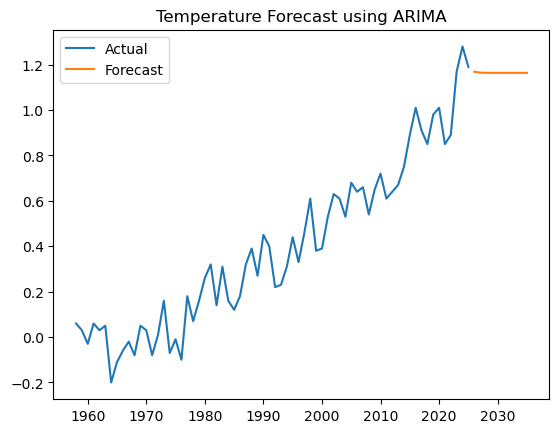

In [41]:
plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')

future_years = range(merged['Year'].iloc[-1]+1, merged['Year'].iloc[-1]+11)
plt.plot(future_years, forecast, label='Forecast')

plt.legend()
plt.title("Temperature Forecast using ARIMA")
plt.show()

In [42]:
model1 = ARIMA(merged['Temperature_anomaly'], order=(1,1,1)).fit()
model2 = ARIMA(merged['Temperature_anomaly'], order=(1,2,1)).fit()

print("AIC (1,1,1):", model1.aic)
print("AIC (1,2,1):", model2.aic)

d:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


AIC (1,1,1): -97.31899608653887
AIC (1,2,1): -87.84762605021476


In [43]:
forecast_2 = model2.forecast(steps=10)
print(forecast_2)

68    1.235286
69    1.245510
70    1.264821
71    1.281777
72    1.299343
73    1.316752
74    1.334201
75    1.351639
76    1.369081
77    1.386521
Name: predicted_mean, dtype: float64


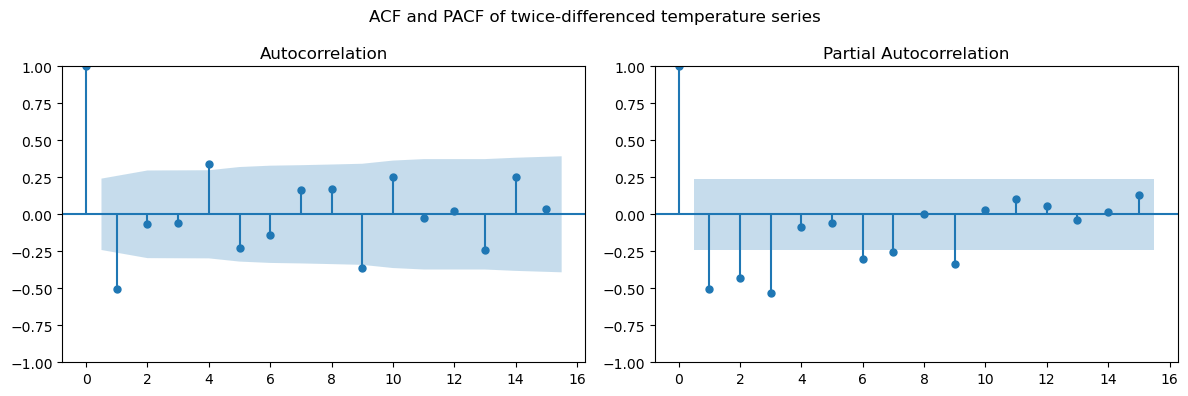

In [44]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(merged['Temperature_anomaly'].diff().diff().dropna(), ax=axes[0], lags=15)
plot_pacf(merged['Temperature_anomaly'].diff().diff().dropna(), ax=axes[1], lags=15)
plt.suptitle('ACF and PACF of twice-differenced temperature series')
plt.tight_layout()
plt.show()

d:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


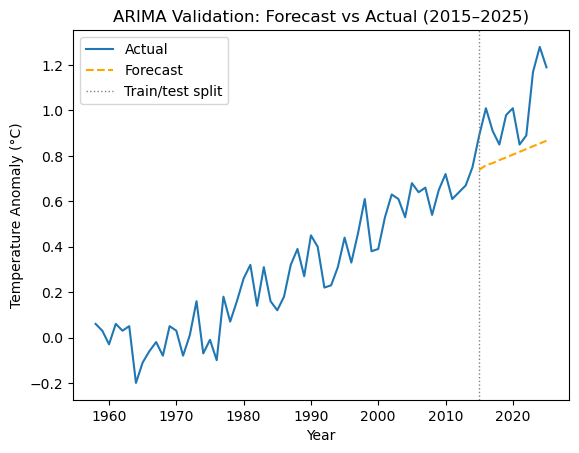

In [45]:
train = merged[merged['Year'] < 2015]['Temperature_anomaly']
test = merged[merged['Year'] >= 2015]['Temperature_anomaly']
test_years = merged[merged['Year'] >= 2015]['Year']  # add this

model_val = ARIMA(train, order=(1, 2, 1)).fit()
forecast_val = model_val.forecast(steps=len(test))

plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')
plt.plot(test_years.values, forecast_val.values, label='Forecast', linestyle='--', color='orange')
plt.axvline(2015, color='grey', linestyle=':', linewidth=1, label='Train/test split')
plt.legend()
plt.title('ARIMA Validation: Forecast vs Actual (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()

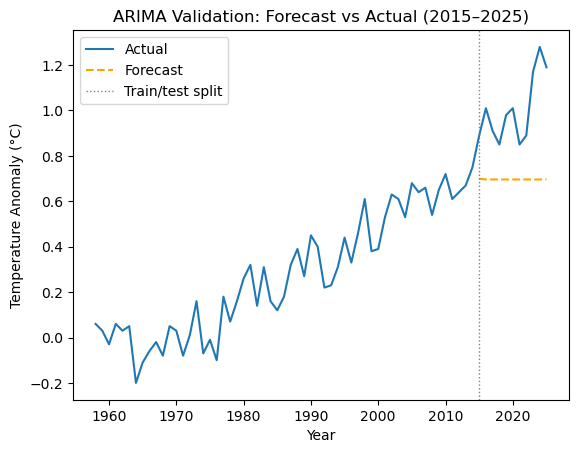

In [54]:
train = merged[merged['Year'] < 2015]['Temperature_anomaly']
test = merged[merged['Year'] >= 2015]['Temperature_anomaly']
test_years = merged[merged['Year'] >= 2015]['Year']  # add this

model_val = ARIMA(train, order=(1, 1, 1)).fit()
forecast_val = model_val.forecast(steps=len(test))

plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')
plt.plot(test_years.values, forecast_val.values, label='Forecast', linestyle='--', color='orange')
plt.axvline(2015, color='grey', linestyle=':', linewidth=1, label='Train/test split')
plt.legend()
plt.title('ARIMA Validation: Forecast vs Actual (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test.values, forecast_val.values)
rmse = np.sqrt(mean_squared_error(test.values, forecast_val.values))

print(f"MAE:  {mae:.4f}°C")
print(f"RMSE: {rmse:.4f}°C")

MAE:  0.2058°C
RMSE: 0.2407°C


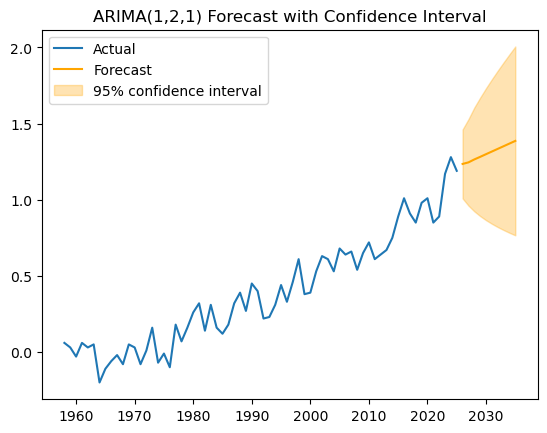

In [48]:
forecast_obj = model2.get_forecast(steps=10)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

future_years = range(merged['Year'].iloc[-1]+1, merged['Year'].iloc[-1]+11)

plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')
plt.plot(future_years, forecast_mean.values, label='Forecast', color='orange')
plt.fill_between(future_years,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.3, color='orange', label='95% confidence interval')
plt.legend()
plt.title('ARIMA(1,2,1) Forecast with Confidence Interval')
plt.show()

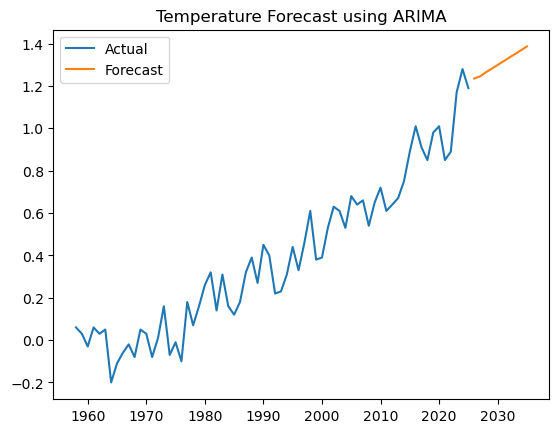

In [49]:
plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')

future_years = range(merged['Year'].iloc[-1]+1, merged['Year'].iloc[-1]+11)
plt.plot(future_years, forecast_2, label='Forecast')

plt.legend()
plt.title("Temperature Forecast using ARIMA")
plt.show()

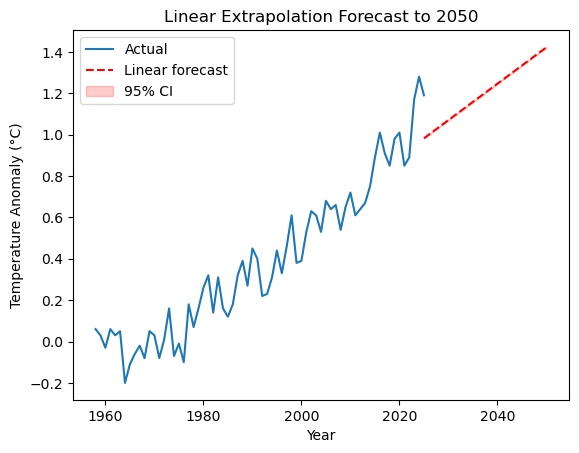

In [50]:
from scipy.stats import linregress

result = linregress(merged['Year'], merged['Temperature_anomaly'])

future_years = np.arange(2025, 2051)
forecast_linear = result.slope * future_years + result.intercept

# Confidence interval
n = len(merged)
se = result.stderr
ci = 1.96 * se * np.sqrt(1 + 1/n + (future_years - merged['Year'].mean())**2 / 
     np.sum((merged['Year'] - merged['Year'].mean())**2))

plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')
plt.plot(future_years, forecast_linear, 'r--', label='Linear forecast')
plt.fill_between(future_years, forecast_linear - ci, forecast_linear + ci,
                 alpha=0.2, color='red', label='95% CI')
plt.legend()
plt.title('Linear Extrapolation Forecast to 2050')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()

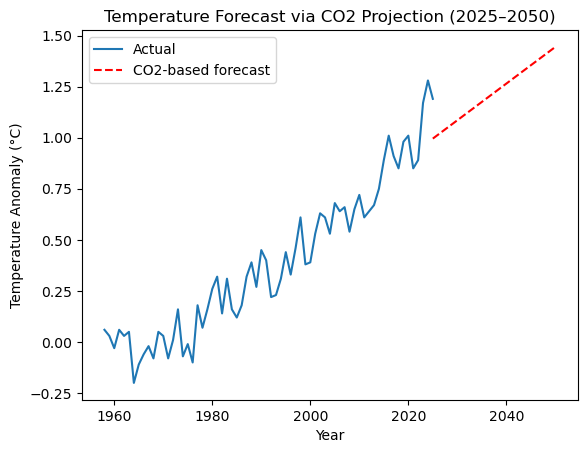

In [51]:
# Project CO2 forward using its own linear trend
co2_result = linregress(co2_yearly['Year'], co2_yearly['Co2'])
future_years = np.arange(2025, 2051)
future_co2 = co2_result.slope * future_years + co2_result.intercept

# Use temperature~CO2 regression to predict temperature
temp_result = linregress(merged['Co2'], merged['Temperature_anomaly'])
future_temp = temp_result.slope * future_co2 + temp_result.intercept

plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')
plt.plot(future_years, future_temp, 'r--', label='CO2-based forecast')
plt.legend()
plt.title('Temperature Forecast via CO2 Projection (2025–2050)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()

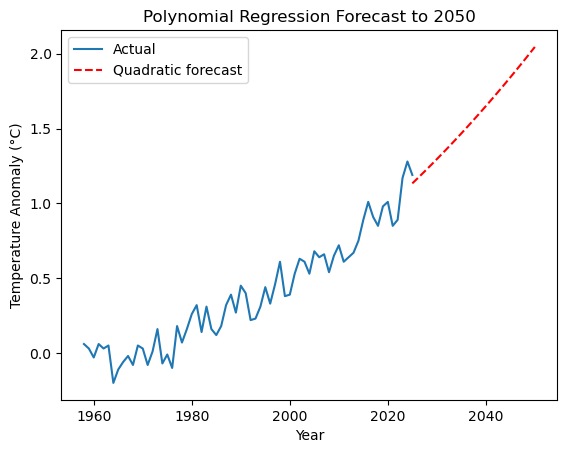

In [52]:
from numpy.polynomial import polynomial as P

# Fit quadratic
coeffs = np.polyfit(merged['Year'], merged['Temperature_anomaly'], 2)

future_years = np.arange(2025, 2051)
forecast_poly = np.polyval(coeffs, future_years)

plt.plot(merged['Year'], merged['Temperature_anomaly'], label='Actual')
plt.plot(future_years, forecast_poly, 'r--', label='Quadratic forecast')
plt.legend()
plt.title('Polynomial Regression Forecast to 2050')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()

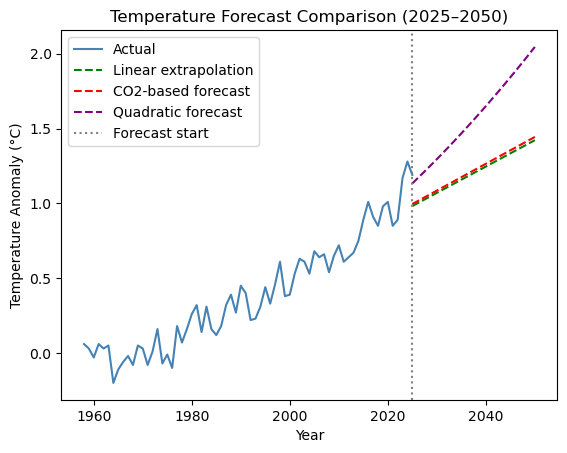

In [53]:
plt.plot(merged['Year'], merged['Temperature_anomaly'], 
         label='Actual', color='steelblue')
plt.plot(future_years, forecast_linear, 
         'g--', label='Linear extrapolation')
plt.plot(future_years, future_temp, 
         'r--', label='CO2-based forecast')
plt.plot(future_years, forecast_poly, 
         'purple', linestyle='--', label='Quadratic forecast')
plt.axvline(2025, color='grey', linestyle=':', label='Forecast start')
plt.legend()
plt.title('Temperature Forecast Comparison (2025–2050)')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.show()